# CS133 Project — P4: Machine Learning

**Team Name**: Group 16  
**Team Members**: Hrishikesh Giri, Srihan Cheemangunta, Yeqing Xu



## Goal

Using Fantasy Premier League (FPL) match-by-match player data, we train regression models to **predict a player's total points in the next gameweek** based on their recent performance history and contextual factors.

We address the following project questions:
- **Q1**: How well can we predict a player's next-game performance using historical statistics?
- **Q2**: How do contextual factors (home/away, opponent strength, value) affect player output?
- **Q4**: Which statistics are the strongest early indicators of a breakout player?
- **Q5**: If a key player is unavailable, can we recommend the best replacement?



## Outline

1. Setup & Data Loading
2. Feature Engineering (Lag / Rolling Features)
3. EDA for ML (Correlations & Distributions)
4. Prepare Data for ML (Split & Pipeline)
5. Train & Compare Models
6. Hyperparameter Tuning
7. Final Evaluation on Test Set
8. Application: Q1 Prediction / Q4 Breakout Indicators / Q5 Replacement Recommendation

## Three ML Models
- LinearRegression
- DecisionTreeRegressor
- RandomForestRegressor


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
print('Libraries loaded.')

Libraries loaded.


In [2]:
# Load FPL gameweek data for two seasons
seasons = ['2024-25', '2025-26']
all_dfs = []

for season in seasons:
    url = f'https://raw.githubusercontent.com/vaastav/Fantasy-Premier-League/master/data/{season}/gws/merged_gw.csv'
    try:
        temp = pd.read_csv(url, encoding='utf-8')
    except UnicodeDecodeError:
        temp = pd.read_csv(url, encoding='latin-1')
    temp['season'] = season
    all_dfs.append(temp)
    print(f'{season}: {temp.shape[0]} rows loaded')

raw = pd.concat(all_dfs, ignore_index=True)
print(f'\nCombined shape: {raw.shape}')
raw.head(3)

2024-25: 27605 rows loaded
2025-26: 22353 rows loaded

Combined shape: (49958, 54)


,name,position,team,xP,assists,bonus,bps,clean_sheets,creativity,element,...,transfers_out,value,was_home,yellow_cards,GW,season,clearances_blocks_interceptions,defensive_contribution,recoveries,tackles
0,Alex Scott,MID,Bournemouth,1.6,0,0,11,0,12.8,77,...,0,50,False,0,1,2024-25,NaN,NaN,NaN,NaN
1,Carlos Miguel dos Santos Pereira,GK,Nott'm Forest,2.2,0,0,0,0,0.0,427,...,0,45,True,0,1,2024-25,NaN,NaN,NaN,NaN
2,Tomiyasu Takehiro,DEF,Arsenal,0.0,0,0,0,0,0.0,22,...,0,50,True,0,1,2024-25,NaN,NaN,NaN,NaN


In [3]:
# Load team strength data to encode opponent difficulty
team_dfs = []
for season in seasons:
    url = f'https://raw.githubusercontent.com/vaastav/Fantasy-Premier-League/master/data/{season}/teams.csv'
    try:
        tdf = pd.read_csv(url)[['id', 'name', 'strength']]
        tdf['season'] = season
        team_dfs.append(tdf)
    except Exception as e:
        print(f'Could not load teams for {season}: {e}')

teams = pd.concat(team_dfs, ignore_index=True)
print('Team data shape:', teams.shape)
teams.head(3)

Team data shape: (40, 4)


,id,name,strength,season
0,1,Arsenal,5,2024-25
1,2,Aston Villa,3,2024-25
2,3,Bournemouth,3,2024-25


In [4]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49958 entries, 0 to 49957
Data columns (total 54 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   name                             49958 non-null  object 
 1   position                         49958 non-null  object 
 2   team                             49958 non-null  object 
 3   xP                               49958 non-null  float64
 4   assists                          49958 non-null  int64  
 5   bonus                            49958 non-null  int64  
 6   bps                              49958 non-null  int64  
 7   clean_sheets                     49958 non-null  int64  
 8   creativity                       49958 non-null  float64
 9   element                          49958 non-null  int64  
 10  expected_assists                 49958 non-null  float64
 11  expected_goal_involvements       49958 non-null  float64
 12  expected_goals    

In [5]:
teams.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        40 non-null     int64 
 1   name      40 non-null     object
 2   strength  40 non-null     int64 
 3   season    40 non-null     object
dtypes: int64(2), object(2)
memory usage: 1.4+ KB



## 2. Feature Engineering

Since we are predicting the **next gameweek's points**, we must engineer features from **past gameweeks only** (no data leakage).

In [6]:
# Basic cleaning
df = raw.copy()

# Filter to outfield positions; drop manager rows
valid_positions = ['GK', 'DEF', 'MID', 'FWD']
df['position'] = df['position'].str.upper().str.strip()
df = df[df['position'].isin(valid_positions)].copy()

# Sort chronologically per player within each season
df = df.sort_values(['season', 'name', 'GW']).reset_index(drop=True)

print('Rows after position filter:', len(df))
print('Positions:', df['position'].value_counts().to_dict())

Rows after position filter: 49636
Positions: {'MID': 22228, 'DEF': 16490, 'FWD': 5479, 'GK': 5439}


In [7]:
# Merge opponent strength
# Map opponent_team id to strength score using the teams table
opp_map = teams.set_index(['season', 'id'])['strength']

def get_opp_strength(row):
    try:
        return opp_map.loc[(row['season'], row['opponent_team'])]
    except KeyError:
        return np.nan

df['opponent_strength'] = df.apply(get_opp_strength, axis=1)
print('Opponent strength NaNs:', df['opponent_strength'].isna().sum())

Opponent strength NaNs: 0


### Use Rolling Features

Each row in the FPL dataset is one player in one gameweek, and these rows are **connected through time** — each player has a chain of games (GW1 → GW2 → GW3 → ...). Using the raw columns from the dataset (like `ict_index`, `creativity`, `threat`) as features directly would be cheating, because the model would be reading the answer at the same time as making the prediction.

To avoid data leakage, we use the information from previous gameweeks. So instead of using GW10's `ict_index`, we use the **average `ict_index` from GW7, GW8, GW9**. This is a **rolling average**.

We compute rolling averages over two windows:
- **3-gameweek window** (`_roll3`): captures short-term hot/cold streaks
- **5-gameweek window** (`_roll5`): captures longer-term form trends

`shift(1)` slides the data back by one row before averaging, so the current gameweek's value is never included in its own feature calculation.

Without `shift(1)`:


| GW | points | rolling(3).mean() includes... |
| -------- | -------- | -------- |
| 10    | 8   | GW8 + GW9 + GW10 ← cheating   |



With `shift(1)`:


| GW | points | shift(1) | rolling(3).mean() includes... |
| -------- | -------- | -------- | -------- |
| 10    | 8   | GW9's value | GW7 + GW8 + GW9 ← honest   |


In [8]:
# Rolling feature factory
rolling_cols = [
    'total_points', 'minutes', 'goals_scored', 'assists',
    'bonus', 'ict_index', 'creativity', 'threat', 'influence',
    'xP', 'expected_goals', 'expected_assists',
    'clean_sheets', 'saves'
]

for col in rolling_cols:
    if col in df.columns:
        # shift(1) so we never include the current gameweek
        df[f'{col}_roll3'] = (
            df.groupby(['season', 'name'])[col]
              .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
        )
        df[f'{col}_roll5'] = (
            df.groupby(['season', 'name'])[col]
              .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
        )

# Lag-1 total points (last gameweek)
df['points_lag1'] = df.groupby(['season', 'name'])['total_points'].transform(lambda x: x.shift(1))

print('Feature engineering done. New columns:', [c for c in df.columns if 'roll' in c or 'lag' in c][:10], '...')

Feature engineering done. New columns: ['total_points_roll3', 'total_points_roll5', 'minutes_roll3', 'minutes_roll5', 'goals_scored_roll3', 'goals_scored_roll5', 'assists_roll3', 'assists_roll5', 'bonus_roll3', 'bonus_roll5'] ...


In [9]:
# Define final feature set and target
# Target: total_points in THIS gameweek
# (we use prior-GW roll features to predict it)

feature_cols_num = [
    'total_points_roll3', 'total_points_roll5', 'points_lag1',
    'minutes_roll3', 'minutes_roll5',
    'ict_index_roll3', 'creativity_roll3', 'threat_roll3', 'influence_roll3',
    'xP_roll3', 'expected_goals_roll3', 'expected_assists_roll3',
    'bonus_roll3', 'goals_scored_roll3', 'assists_roll3',
    'clean_sheets_roll3', 'saves_roll3',
    'value', 'opponent_strength'
]
feature_cols_cat = ['position', 'was_home']
target_col = 'total_points'

all_feature_cols = feature_cols_num + feature_cols_cat

# Filter 1: skip the first 3 GWs per player (no rolling history yet)
# Filter 2: remove rows where the player did not play (minutes = 0)
#   - these rows are noise: the model has nothing to learn from a
#     player who sat on the bench. We keep them in df so their zero-minute
#     games are still captured in other players' rolling averages, but we
#     exclude them as prediction targets.
ml_df = (
    df[(df['GW'] > 3) & (df['minutes'] > 0)]
    [all_feature_cols + [target_col, 'season', 'name', 'GW']]
    .dropna(subset=feature_cols_num[:3])
    .copy()
)

print('ML dataset shape:', ml_df.shape)
print(f'Removed {len(df[df["GW"] > 3]) - len(ml_df):,} non-playing rows')
print(f'\nTarget stats after filter:')
print(f'  Mean:   {ml_df[target_col].mean():.2f}')
print(f'  Median: {ml_df[target_col].median():.1f}')
print(f'  % rows with 0 pts: {(ml_df[target_col] == 0).mean()*100:.1f}%')

ML dataset shape: (18485, 25)
Removed 27,149 non-playing rows

Target stats after filter:
  Mean:   2.83
  Median: 2.0
  % rows with 0 pts: 5.4%



## 3. EDA for ML — Correlations & Target Distribution

We do a sanity check before traning to see if our target is predictable, or our features are actually related to the target.

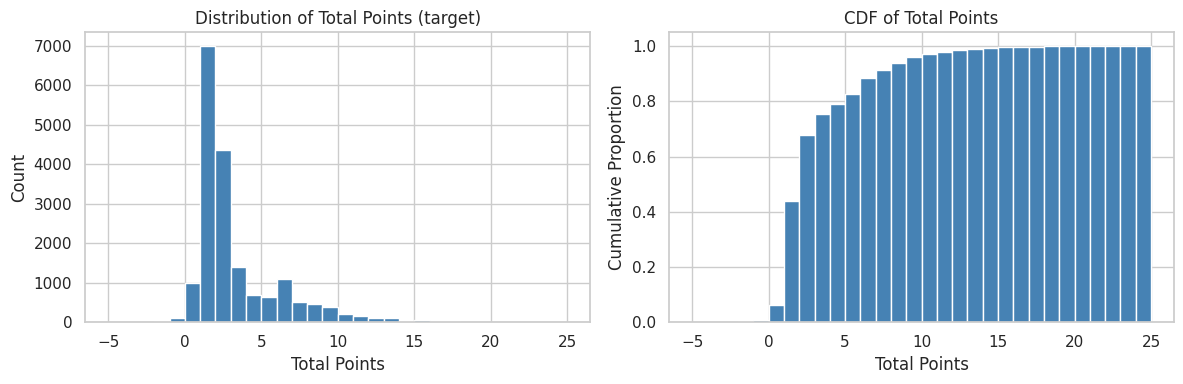

Mean: 2.83   Median: 2.0


In [10]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(ml_df[target_col], bins=30, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Total Points')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Total Points (target)')

axes[1].hist(ml_df[target_col], bins=30, color='steelblue', edgecolor='white', cumulative=True, density=True)
axes[1].set_xlabel('Total Points')
axes[1].set_ylabel('Cumulative Proportion')
axes[1].set_title('CDF of Total Points')

plt.tight_layout()
plt.show()
print('Mean:', ml_df[target_col].mean().round(2), '  Median:', ml_df[target_col].median())

The histogram (left) displays how often each points total appears across all player-gameweeks in the dataset. The CDF (right) shows the cumulative proportion.

The mean is **2.83** and median is **2.0**, which reflects a realistic playing population. The distribution is still right-skewed, showing that most players score 1–4 points in a typical gameweek, while 10+ point hauls are rare.

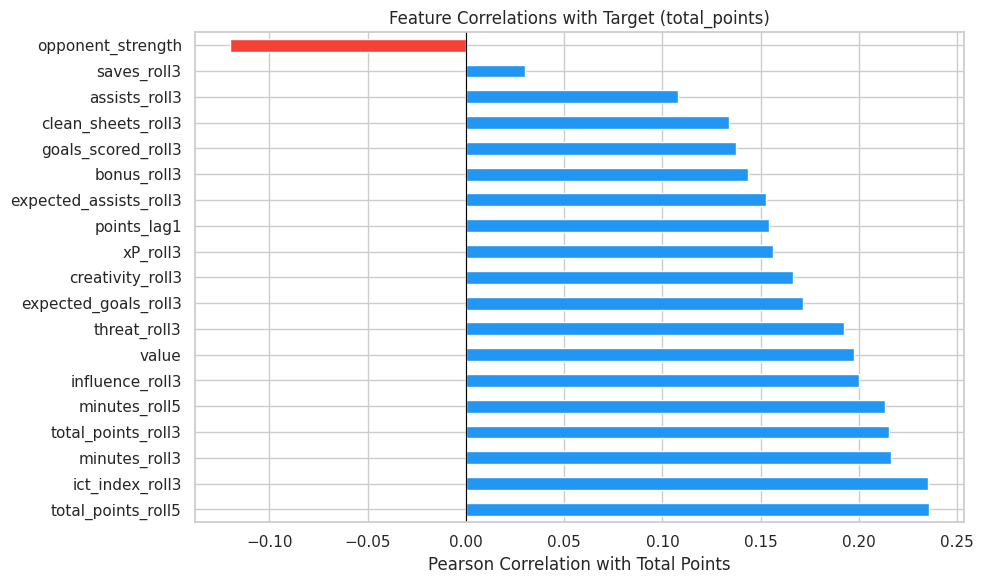

In [11]:
# Correlation of numeric features with target
corr = ml_df[feature_cols_num + [target_col]].corr()[target_col].drop(target_col).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#2196F3' if v > 0 else '#F44336' for v in corr]
corr.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Pearson Correlation with Total Points')
plt.title('Feature Correlations with Target (total_points)')
plt.tight_layout()
plt.show()

Each bar is the Pearson correlation between one feature and `total_points`. Blue bars (positive) mean the feature and points tend to move together. A bar close to 0 means little linear relationship.

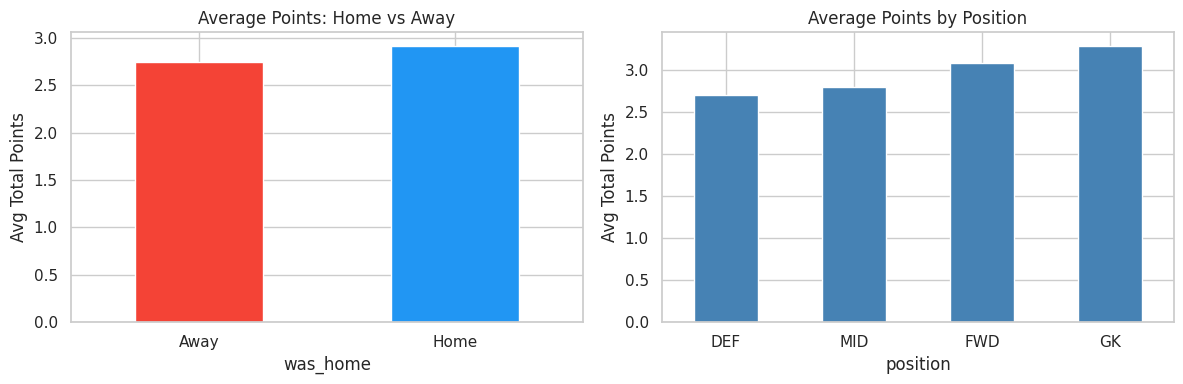

In [12]:
# Home vs Away average points
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ml_df.groupby('was_home')[target_col].mean().plot(
    kind='bar', ax=axes[0], color=['#F44336', '#2196F3'], edgecolor='white'
)
axes[0].set_xticklabels(['Away', 'Home'], rotation=0)
axes[0].set_title('Average Points: Home vs Away')
axes[0].set_ylabel('Avg Total Points')

ml_df.groupby('position')[target_col].mean().sort_values().plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='white'
)
axes[1].set_title('Average Points by Position')
axes[1].set_ylabel('Avg Total Points')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

Left chart: Average total points split by whether the player was at home or away. Home players score slightly more on average.

Right chart: Average total points by position. Forwards and midfielders tend to average more points than defenders and goalkeepers because the FPL scoring system rewards goals and assists heavily.

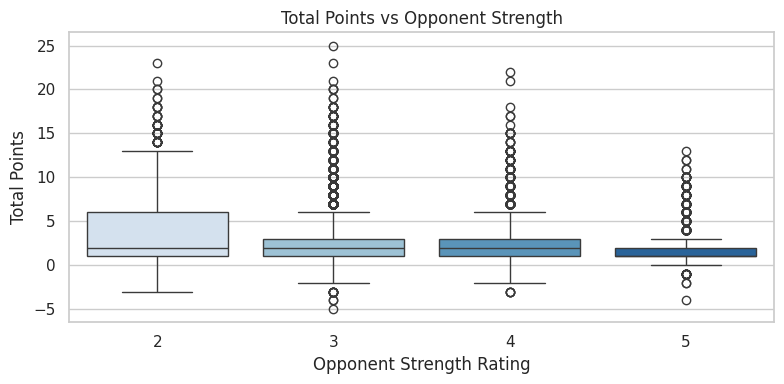

In [13]:
# Opponent strength vs points scored
plt.figure(figsize=(8, 4))
sns.boxplot(data=ml_df, x='opponent_strength', y=target_col, palette='Blues')
plt.title('Total Points vs Opponent Strength')
plt.xlabel('Opponent Strength Rating')
plt.ylabel('Total Points')
plt.tight_layout()
plt.show()

Each box represents all player-gameweek rows facing a given opponent strength rating (2 = weakest, 5 = strongest).


## 4. Prepare Data for ML

We use a **temporal train/test split**: the 2024-25 season is training data and the most recent gameweeks of 2025-26 are the test set. This mirrors real-world usage, that is we train on past seasons and predict the current one.

In [14]:
# Temporal split: train on 2024-25, test on 2025-26
train_df = ml_df[ml_df['season'] == '2024-25'].copy()
test_df  = ml_df[ml_df['season'] == '2025-26'].copy()

X_train = train_df[all_feature_cols]
y_train = train_df[target_col]

X_test = test_df[all_feature_cols]
y_test = test_df[target_col]

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')

Training set: 10620 samples
Test set:     7865 samples


In [15]:
# Build sklearn preprocessing pipeline
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, feature_cols_num),
    ('cat', categorical_transformer, feature_cols_cat)
])

print('Preprocessor built.')

Preprocessor built.



## 5. Train & Compare Models

We evaluate three models using **5-fold cross-validation** on the training set:
- **Linear Regression** — simple baseline
- **Decision Tree Regressor** — captures non-linear patterns
- **Random Forest Regressor** — ensemble, more robust

In [16]:
models = {
    'Linear Regression':    LinearRegression(),
    'Decision Tree':        DecisionTreeRegressor(random_state=42),
    'Random Forest':        RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

cv_results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    scores = cross_val_score(pipe, X_train, y_train,
                             cv=5, scoring='neg_root_mean_squared_error',
                             n_jobs=-1)
    rmse_scores = -scores
    cv_results[name] = rmse_scores
    print(f'{name:25s}  CV RMSE: {rmse_scores.mean():.3f} ± {rmse_scores.std():.3f}')

Linear Regression          CV RMSE: 2.737 ± 0.159
Decision Tree              CV RMSE: 4.135 ± 0.207
Random Forest              CV RMSE: 2.812 ± 0.152



## 6. Hyperparameter Tuning




## 7. Final Evaluation on Test Set

We evaluate the best tuned model on the held-out 2025-26 season data.


## 8. Application (Q1, Q4, and Q5?)



---
## Summary

| Model | CV RMSE |
|---|---|
| Linear Regression | (see cell output above) |
| Decision Tree | (see cell output above) |
| Random Forest (tuned) | (best — see cell output above) |

**Key Findings:**

- **Q1**:
- **Q2**:
- **Q3**:
- **Q4**:
- **Q5**:

**Limitations**: